<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAE               : 0.3960
RMSE              : 0.3680
R² Score          : 0.8071
Adjusted R² Score : 0.8065


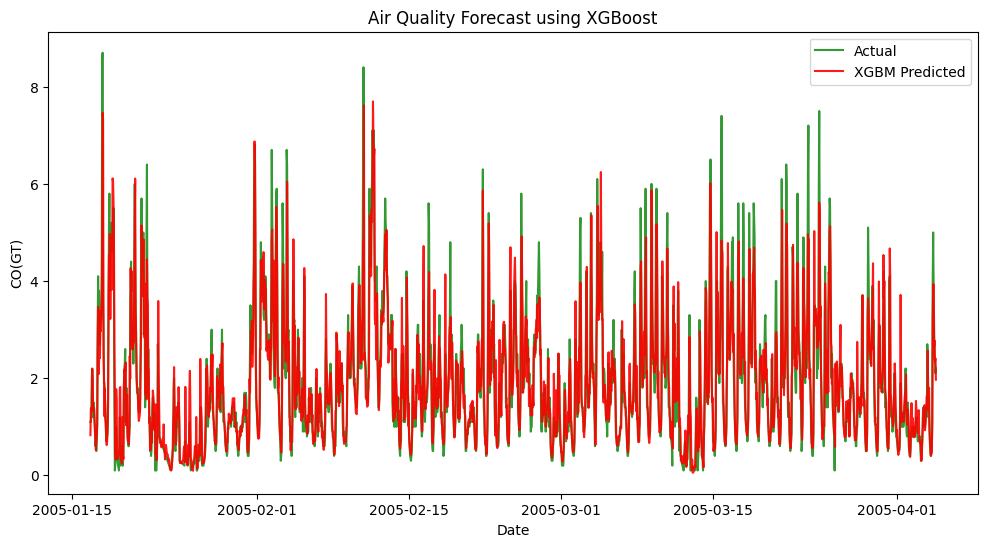

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import time
#Load the dataset
air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=";", decimal=",")
#Data preprocessing
air_quality_df = air_quality_df.dropna(axis=1, how="all")
air_quality_df = air_quality_df.dropna(subset=["Date", "Time"])
air_quality_df["Datetime"] = pd.to_datetime(
    air_quality_df["Date"] + " " + air_quality_df["Time"],
    format="%d/%m/%Y %H.%M.%S")
air_quality_df = air_quality_df.set_index("Datetime").drop(
    columns=["Date", "Time"]
)
numeric_cols = ["CO(GT)","PT08.S1(CO)","NMHC(GT)","C6H6(GT)","PT08.S2(NMHC)","NOx(GT)","PT08.S3(NOx)",
    "NO2(GT)","PT08.S4(NO2)", "PT08.S5(O3)","T","RH","AH",]

for col in numeric_cols:
    if col in air_quality_df.columns:
        air_quality_df[col] = pd.to_numeric(
            air_quality_df[col], errors="coerce"
        )
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].replace(-200, np.nan)
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].interpolate(
    method="linear")
air_quality_df["CO(GT)"] = air_quality_df["CO(GT)"].bfill().ffill()
target_column = "CO(GT)"
air_quality_df = air_quality_df.dropna(subset=[target_column])
air_quality_df = air_quality_df.sort_index()
#Feature selectiob
df_lgb = air_quality_df.copy()
# Extract cyclical time features
df_lgb["Hour"] = df_lgb.index.hour
df_lgb["DayOfWeek"] = df_lgb.index.dayofweek

# Create Lag Features (adjust range to match your LSTM(To compare) lookback window length)
for lag in range(1, 4):
    df_lgb[f"CO_lag_{lag}"] = df_lgb["CO(GT)"].shift(lag)

# Create a Rolling Mean feature to capture recent trajectory trends
df_lgb["CO_rolling_mean_3h"] = (
    df_lgb["CO(GT)"].shift(1).rolling(window=3).mean())

# Drop the edge boundary rows containing NaNs created by shifting/rolling
df_tabular = df_lgb.dropna()

# Select feature columns (excluding target or unrelated metrics)
feature_cols = ["Hour","DayOfWeek","CO_lag_1","CO_lag_2","CO_lag_3","CO_rolling_mean_3h"]
X = df_tabular[feature_cols]
y = df_tabular["CO(GT)"]
# Splitting dataset for training and testing
split_index = int(len(df_tabular) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Initialize XGBoost Regressor
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
)
#Fit the model
model.fit(X_train, y_train)
end_train = time.perf_counter()
#Forecast the model
predictions = model.predict(X_test)
#Accuracy metrics
y_true = y_test.values
y_pred = predictions

# MAE, RMSE, and R2
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Adjusted R2
n = len(y_true)  # Number of data points in test set
p = X_train.shape[1]  # Number of features/predictors used (3 lags)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")
# VISUALIZE LIGHTGBM RESULTS
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual", color="green", alpha=0.8)
plt.plot(y_test.index,predictions,label="XGBM Predicted",color="red",alpha=0.9)
plt.title("Air Quality Forecast using XGBoost")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.show()